In [50]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import seaborn as sns


Preprocessing data for classification

In [51]:
# reading all files consists of:
#1-bluesky data tagged by ranaa 
#2- tweeter data tagged by rana
#3- tweeter data from Abish paper (filtererd by Alex)

df_bluesky_rana = pd.read_csv('rana_tagged_data_clean/bluesky_rana_tagged_clean.csv', dtype=str)
df_tweet_rana = pd.read_csv('rana_tagged_data_clean/tweeter_rana_tagged_clean.csv', dtype=str)
df_tweet_filtered = pd.read_csv('tweet_AbishFiltered_data/human_categorized_data.csv', dtype=str)

len(df_tweet_filtered), len(df_tweet_rana), len(df_bluesky_rana),

(41189, 2205, 2002)

In [52]:
df_tweet_rana

,id,text,Educator
0,1.82e+18,Book me for your next event. I am available fo...,0
1,1.82e+18,"#ChatGPT for #education: Analysis, evaluation ...",0
2,1.82e+18,"AI Course Creator is NOW LIVE, a revolutionary...",1
3,1.82e+18,3) What was your experience like testing DALL-...,1
4,1.82e+18,How are you leveraging @getpostman to test and...,0
...,...,...,...
2200,1.8192853090638968e+18,GitHub Models is a new feature that allows use...,0
2201,1.819284735274652e+18,Check out my new Oracle Cloud Infrastructure 2...,0
2202,1.819282098550641e+18,Have you used videos to help train a new emplo...,0
2203,1.819282098437452e+18,Have you used videos to help train a new emplo...,0


In [54]:
# For df_tweet_rana: select only 'text' and 'Educator'
df_Rtweet = df_tweet_rana[["text", "Educator"]].copy()
df_Rtweet.columns = ['text', 'label']

# Now df_rana has two columns: text and Educator

# For df_bluesky_rana: select only 'text' and 'Educator'
df_Rbluesky = df_bluesky_rana[["text", "Educator"]].copy()
df_Rbluesky.columns = ['text', 'label']

# Now df_bluesky has two columns: text and Educator

# For df_tweet_filtered: select only 'text' and 'Label'
df_Ftweet = df_tweet_filtered[["text", "Label"]].copy()
df_Ftweet.columns = ['text', 'label']
df_Ftweet

,text,label
0,username i just left academia former assistant...,1
1,gpt3 this post on lesswrong discusses the pote...,0
2,openai gpt35 series of models if youre a rese...,0
3,we further exam the quality of the generated s...,0
4,for decades many people in academia have treat...,0
...,...,...
41184,username some dude did this to our group in an...,1
41185,btw there are various pieces of news how gpt d...,0
41186,rhett mankind a digital artist based in austra...,0
41187,my professor is saying she has no issue with u...,1


In [55]:
df_Rtweet

,text,label
0,Book me for your next event. I am available fo...,0
1,"#ChatGPT for #education: Analysis, evaluation ...",0
2,"AI Course Creator is NOW LIVE, a revolutionary...",1
3,3) What was your experience like testing DALL-...,1
4,How are you leveraging @getpostman to test and...,0
...,...,...
2200,GitHub Models is a new feature that allows use...,0
2201,Check out my new Oracle Cloud Infrastructure 2...,0
2202,Have you used videos to help train a new emplo...,0
2203,Have you used videos to help train a new emplo...,0


In [56]:
def del_red_rows(df):
    # Identify redundant rows (duplicates of text & Educator), keeping the first occurrence
    mask = df.duplicated(subset=['text', 'label'], keep='first')

    # Get the indices of those redundant rows
    redundant_indices = df.index[mask].tolist()
    print("Number of Redundant rows:", len(redundant_indices))
    print("Indices of redundant rows:", redundant_indices)
    df = df.drop(index=redundant_indices).reset_index(drop=True)

    return df

df_Rtweet = del_red_rows(df_Rtweet)
print()
df_Rbluesky = del_red_rows(df_Rbluesky)
print()
df_Ftweet = del_red_rows(df_Ftweet)

df_Rtweet

Number of Redundant rows: 697
Indices of redundant rows: [598, 601, 832, 833, 834, 917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927, 928, 929, 930, 931, 932, 933, 934, 935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946, 947, 948, 949, 950, 951, 952, 953, 954, 955, 956, 957, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968, 969, 970, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1081, 1082, 1083

,text,label
0,Book me for your next event. I am available fo...,0
1,"#ChatGPT for #education: Analysis, evaluation ...",0
2,"AI Course Creator is NOW LIVE, a revolutionary...",1
3,3) What was your experience like testing DALL-...,1
4,How are you leveraging @getpostman to test and...,0
...,...,...
1503,Pan-African school network Nova Pioneer has st...,0
1504,Check out my new Oracle Cloud Infrastructure 2...,0
1505,Have you used videos to help train a new emplo...,0
1506,Have you used videos to help train a new emplo...,0


In [57]:
#checking for NaN

for name, df in [("df1", df_Ftweet), ("df2", df_Rtweet), ("df3", df_Rbluesky)]:
    has_nan = df.isna().any().any()
    print(f"{name} contains NaN? {has_nan}")
    if has_nan:
        # Show how many NaNs per column
        nan_counts = df.isna().sum()
        print(f"  NaN counts by column:\n{nan_counts[nan_counts > 0]}\n")

df1 contains NaN? False
df2 contains NaN? True
  NaN counts by column:
text    1
dtype: int64

df3 contains NaN? False


In [58]:
# 2) View all rows that have at least one NaN
rows_with_nan = df_Rtweet[df_Rtweet.isna().any(axis=1)]
print("\nRows containing NaN values:\n", rows_with_nan)

# 3) Drop any row that contains a NaN (modify in place)
df_Rtweet.dropna(inplace=True)

# 4) (Optional) Verify no NaNs remain
print("\nRemaining NaN count:\n", df_Rtweet.isna().sum().sum())


Rows containing NaN values:
      text label
1033  NaN     0

Remaining NaN count:
 0


In [59]:
df_combined = pd.concat([df_Ftweet, df_Rbluesky, df_Rtweet], ignore_index=True)
df_combined

,text,label
0,username i just left academia former assistant...,1
1,gpt3 this post on lesswrong discusses the pote...,0
2,openai gpt35 series of models if youre a rese...,0
3,we further exam the quality of the generated s...,0
4,for decades many people in academia have treat...,0
...,...,...
39212,Pan-African school network Nova Pioneer has st...,0
39213,Check out my new Oracle Cloud Infrastructure 2...,0
39214,Have you used videos to help train a new emplo...,0
39215,Have you used videos to help train a new emplo...,0


In [60]:
x_clean = df_combined['text']
y_clean = df_combined['label']

x_clean_train, x_clean_test, y_clean_train, y_clean_test = train_test_split(x_clean, y_clean, test_size=0.2, shuffle=True)


# Uses TF-IDF transformation
tfidf = TfidfVectorizer()
bin_train_vals = tfidf.fit_transform(x_clean_train.to_numpy(dtype=str))
bin_test_vals = tfidf.transform(x_clean_test.to_numpy(dtype=str))

# SVM (binary class)
svm_bin = LinearSVC()
svm_bin.fit(bin_train_vals, y_clean_train.to_numpy(dtype=int))
svm_bin_preds = svm_bin.predict(bin_test_vals)

print('Recall:', recall_score(y_clean_test.to_numpy(dtype=int), svm_bin_preds), 'Precision:', precision_score(y_clean_test.to_numpy(dtype=int), svm_bin_preds))
print('F1 Score:', f1_score(y_clean_test.to_numpy(dtype=int), svm_bin_preds))

Recall: 0.9518850987432675 Precision: 0.9844040103973264
F1 Score: 0.9678714859437751


Train=Ftweet → Test=Rtweet+Rbluesky → Accuracy: 0.7717, F1: 0.0846


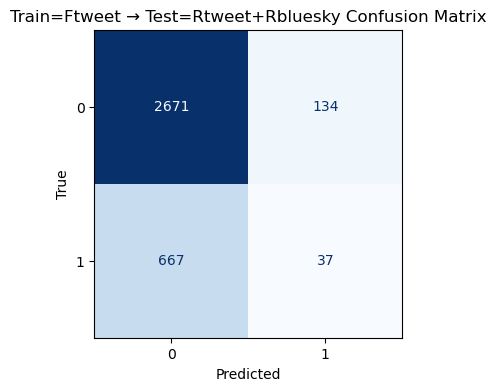

Train=Rtweet+Rbluesky → Test=Ftweet → Accuracy: 0.6254, F1: 0.2348


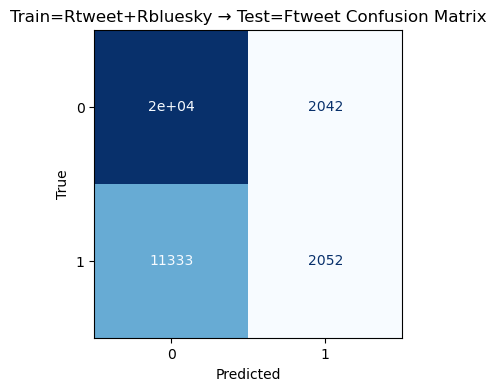

In [61]:


# ─── 1. Prepare the data ─────────────────────────────────────────────────────

# Convert labels to int (if they’re not already)
df_Ftweet["label"] = df_Ftweet["label"].astype(int)
df_Rtweet["label"] = df_Rtweet["label"].astype(int)
df_Rbluesky["label"] = df_Rbluesky["label"].astype(int)

# Combine df_Rtweet and df_Rbluesky into one DataFrame for “R” dataset
df_R_combined = pd.concat([df_Rtweet, df_Rbluesky], ignore_index=True)

# ─── 2. Define a helper to train + evaluate ────────────────────────────────────
def train_and_evaluate(X_train, y_train, X_test, y_test, title=""):
    """
    Trains a LinearSVC on (X_train, y_train) using TF-IDF features,
    then evaluates on (X_test, y_test), printing accuracy + F1,
    and plotting the confusion matrix with `title`.
    """
    # Vectorize
    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Train SVM
    clf = LinearSVC()
    clf.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = clf.predict(X_test_tfidf)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")

    print(f"{title} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.show()


# ─── 3. Experiment 1: Train on F-tweets → Test on R-tweets + R-bluesky ──────────
X_train_F = df_Ftweet["text"].tolist()
y_train_F = df_Ftweet["label"].tolist()

X_test_R = df_R_combined["text"].tolist()
y_test_R = df_R_combined["label"].tolist()

train_and_evaluate(
    X_train=X_train_F,
    y_train=y_train_F,
    X_test=X_test_R,
    y_test=y_test_R,
    title="Train=Ftweet → Test=Rtweet+Rbluesky"
)


# ─── 4. Experiment 2: Train on R-tweets + R-bluesky → Test on F-tweets ──────────
X_train_R = df_R_combined["text"].tolist()
y_train_R = df_R_combined["label"].tolist()

X_test_F = df_Ftweet["text"].tolist()
y_test_F = df_Ftweet["label"].tolist()

train_and_evaluate(
    X_train=X_train_R,
    y_train=y_train_R,
    X_test=X_test_F,
    y_test=y_test_F,
    title="Train=Rtweet+Rbluesky → Test=Ftweet"
)



=== Train on 80% / Test on 20% (All data) ===
Accuracy: 0.9758, F1: 0.9656



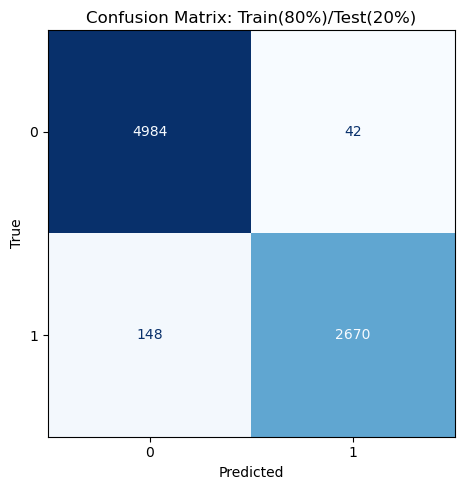

In [69]:
# 1c) Concatenate into one big DataFrame
df_all = pd.concat([df_Ftweet, df_Rtweet, df_Rbluesky], ignore_index=True)

# ─── 2. Split 80/20 for train/test ────────────────────────────────────────────

# 2a) Separate texts and labels
X = df_all["text"].tolist()
y = df_all["label"].tolist()

# 2b) Stratified split to preserve label distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ─── 3. Vectorize & train SVM ─────────────────────────────────────────────────

# 3a) Fit TF-IDF on training text
vectorizer     = TfidfVectorizer()
X_train_tfidf  = vectorizer.fit_transform(X_train)
X_test_tfidf   = vectorizer.transform(X_test)

# 3b) Train LinearSVC on the TF-IDF features
clf = LinearSVC()
clf.fit(X_train_tfidf, y_train)

# ─── 4. Evaluate on held-out 20% ──────────────────────────────────────────────

# 4a) Predict on test split
y_pred = clf.predict(X_test_tfidf)

# 4b) Compute metrics
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average="binary")
print(f"\n=== Train on 80% / Test on 20% (All data) ===")
print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}\n")

# 4c) Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
ax.set_title("Confusion Matrix: Train(80%)/Test(20%)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()


In [71]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Recombine X and y into arrays for cross-validation:
X_arr = np.array(X)
y_arr = np.array(y)

# Vectorize all texts once:
full_tfidf = vectorizer.fit_transform(X_arr)

# 5-fold stratified CV:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = cross_val_score(clf, full_tfidf, y_arr, cv=skf, scoring="accuracy")
f1_scores  = cross_val_score(clf, full_tfidf, y_arr, cv=skf, scoring="f1")

print("5-fold CV accuracy:", np.round(acc_scores, 4))
print("5-fold CV F1:      ", np.round(f1_scores, 4))
print("Mean accuracy:", acc_scores.mean(), "±", acc_scores.std())
print("Mean F1:      ", f1_scores.mean(),  "±", f1_scores.std())


5-fold CV accuracy: [0.9791 0.9764 0.9779 0.9779 0.9787]
5-fold CV F1:       [0.9703 0.9664 0.9686 0.9687 0.9698]
Mean accuracy: 0.9780197499070716 ± 0.0009175865429524575
Mean F1:       0.9687776311673684 ± 0.001346264322209836


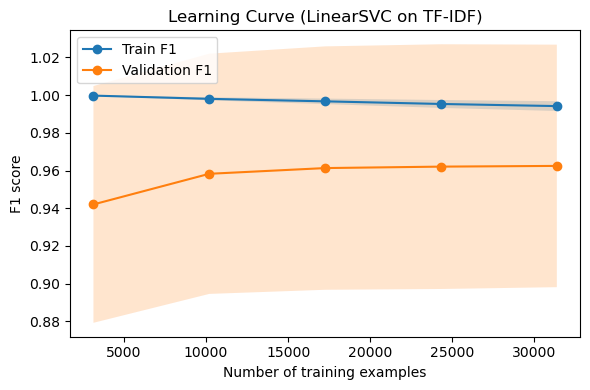

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Use the same TF-IDF + LinearSVC pipeline in a single estimator:
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(
    TfidfVectorizer(),
    LinearSVC()
)

# Generate learning curve data
train_sizes, train_scores, valid_scores = learning_curve(
    pipe,
    X,             # list of raw texts
    y,             # labels
    cv=5,          # 5-fold stratified
    train_sizes=np.linspace(0.1, 1.0, 5), 
    scoring="f1",
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std  = np.std(valid_scores,  axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean,  'o-', label="Train F1")
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.plot(train_sizes, valid_mean,  'o-', label="Validation F1")
plt.fill_between(train_sizes,
                 valid_mean - valid_std,
                 valid_mean + valid_std,
                 alpha=0.2)

plt.title("Learning Curve (LinearSVC on TF-IDF)")
plt.xlabel("Number of training examples")
plt.ylabel("F1 score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


Dataset Bian Checking

In [73]:
import pandas as pd

# Assume df_all is the concatenated DataFrame with a column named "label"
label_counts = df_all["label"].value_counts()
label_props  = (label_counts / len(df_all)).round(3)

print("Label counts:\n", label_counts)
print("\nLabel proportions:\n", label_props)


Label counts:
 label
0    25128
1    14089
Name: count, dtype: int64

Label proportions:
 label
0    0.641
1    0.359
Name: count, dtype: float64


In [74]:
majority_label = label_counts.idxmax()
majority_frac  = label_props[majority_label]
print(f"Majority‐class baseline accuracy: {majority_frac:.3f}")


Majority‐class baseline accuracy: 0.641


In [75]:
# 1) Create sets of text in train vs. test
train_texts = set(X_train)
test_texts  = set(X_test)

# 2) Find overlaps
overlap = train_texts.intersection(test_texts)
print(f"Number of duplicate‐text overlaps between train & test: {len(overlap)}")

if overlap:
    print("Example overlap:", list(overlap)[:5])


Number of duplicate‐text overlaps between train & test: 0


In [77]:
!pip install rapidfuzz

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 7.9 MB/s eta 0:00:00


In [78]:
from rapidfuzz import fuzz

def has_similar(text, text_set, threshold=95):
    # Returns True if text matches any in text_set with similarity ≥ threshold
    return any(fuzz.ratio(text, t2) >= threshold for t2 in text_set)

duplicates = []
for t in list(test_texts)[:200]:  # sample 200 texts from test
    if has_similar(t, train_texts):
        duplicates.append(t)
print(f"Number of near‐duplicates in sample: {len(duplicates)}")


Number of near‐duplicates in sample: 9


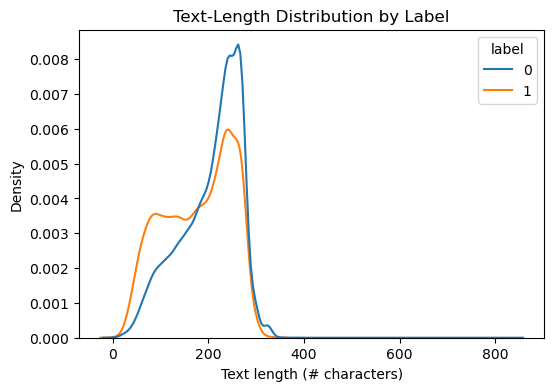

In [79]:
df_all["text_len"] = df_all["text"].str.len()

import seaborn as sns, matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.kdeplot(data=df_all, x="text_len", hue="label", common_norm=False)
plt.title("Text‐Length Distribution by Label")
plt.xlabel("Text length (# characters)")
plt.show()


In [84]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=5000)
X_counts = vectorizer.fit_transform(df_all["text"])
vocab    = vectorizer.get_feature_names_out()

# Split by label
labels = df_all["label"].values
counts_0 = X_counts[labels==0].sum(axis=0).A1
counts_1 = X_counts[labels==1].sum(axis=0).A1

top5_0 = [vocab[i] for i in counts_0.argsort()[-10:][::-1]]
top5_1 = [vocab[i] for i in counts_1.argsort()[-10:][::-1]]

print("Top 10 words for label=0:", top5_0)
print("Top 10 words for label=1:", top5_1)


Top 10 words for label=0: ['chatgpt', 'ai', 'username', 'research', 'prompt', 'use', 'course', 'gpt', 'like', 'students']
Top 10 words for label=1: ['chatgpt', 'teacher', 'username', 'professor', 'ai', 'students', 'use', 'gpt', 'education', 'like']


In [ ]:
# check labels for teacher

Label counts:
 label
0    22323
1    13385
Name: count, dtype: int64

Label proportions:
 label
0    0.625
1    0.375
Name: count, dtype: float64


C:\Users\kiara\AppData\Local\Temp\ipykernel_44124\981376588.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index.astype(str), y=label_counts.values, palette="pastel")


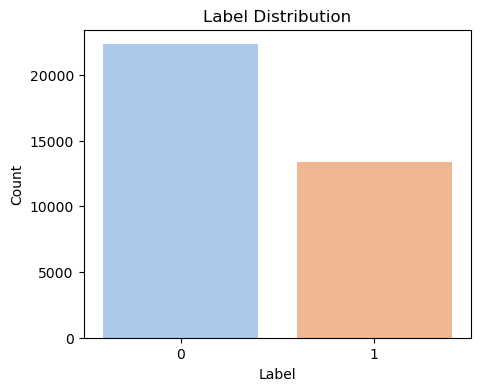

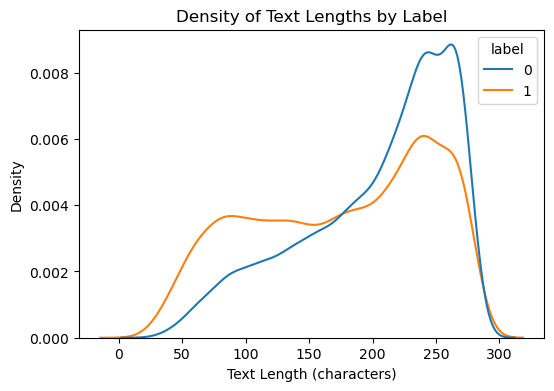

Label counts:
 label
0    1348
1     159
Name: count, dtype: int64

Label proportions:
 label
0    0.894
1    0.106
Name: count, dtype: float64


C:\Users\kiara\AppData\Local\Temp\ipykernel_44124\981376588.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index.astype(str), y=label_counts.values, palette="pastel")


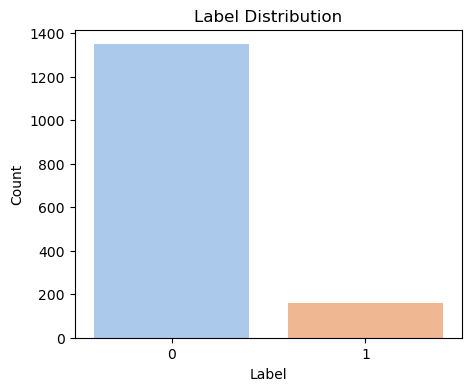

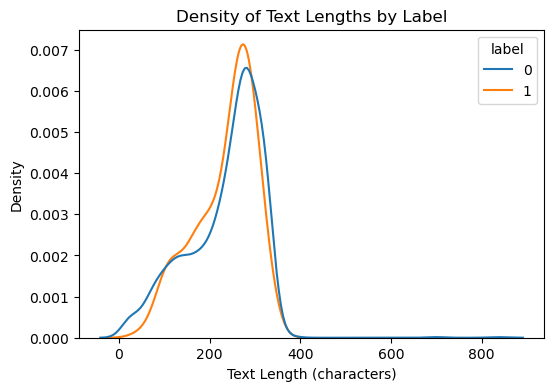

Label counts:
 label
0    1457
1     545
Name: count, dtype: int64

Label proportions:
 label
0    0.728
1    0.272
Name: count, dtype: float64


C:\Users\kiara\AppData\Local\Temp\ipykernel_44124\981376588.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index.astype(str), y=label_counts.values, palette="pastel")


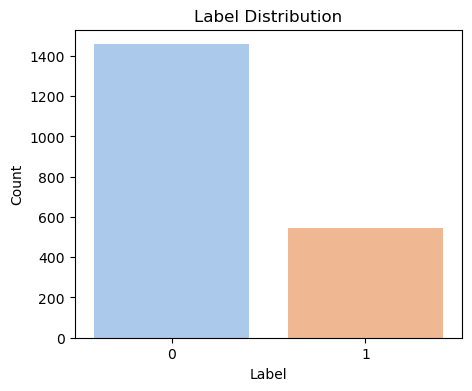

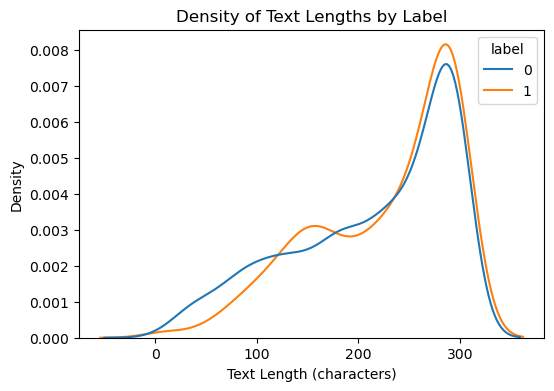

In [68]:
def bias_check(df):
    # ─── 1. Basic Label Distribution ───────────────────────────────────────────────
    # # Count how many 0s vs. 1s (or negative vs. positive)
    label_counts = df["label"].value_counts(dropna=False)
    print("Label counts:\n", label_counts)
    print("\nLabel proportions:\n", (label_counts / len(df)).round(3))
    
    # Plot as a bar chart
    plt.figure(figsize=(5, 4))
    sns.barplot(x=label_counts.index.astype(str), y=label_counts.values, palette="pastel")
    plt.title("Label Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()
    
    # ─── 2. Text Length Distribution by Label ─────────────────────────────────────
    # (Sometimes skewed text‐lengths per class hint at dataset artifacts.)
    df["text_len"] = df["text"].str.len()
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x="text_len", hue="label", common_norm=False)
    plt.title("Density of Text Lengths by Label")
    plt.xlabel("Text Length (characters)")
    plt.ylabel("Density")
    plt.show()

bias_check(df_Ftweet)
bias_check(df_Rtweet)
bias_check(df_Rbluesky)

Label counts:
 label
0    25128
1    14089
Name: count, dtype: int64

Label proportions:
 label
0    0.641
1    0.359
Name: count, dtype: float64


C:\Users\kiara\AppData\Local\Temp\ipykernel_44124\981376588.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index.astype(str), y=label_counts.values, palette="pastel")


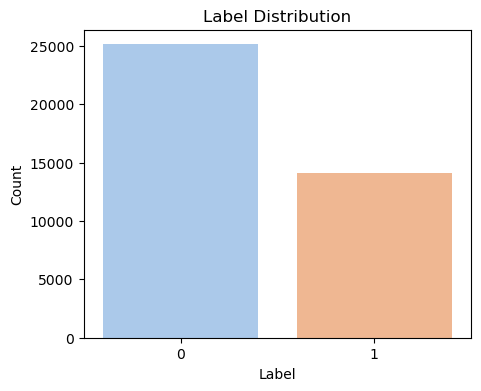

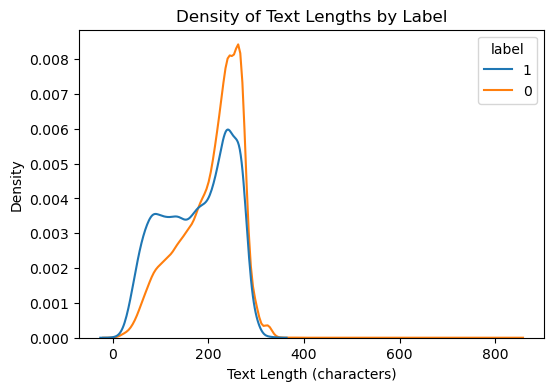

In [81]:
bias_check(df_combined)

Accuracy: 0.7991, F1: 0.4000


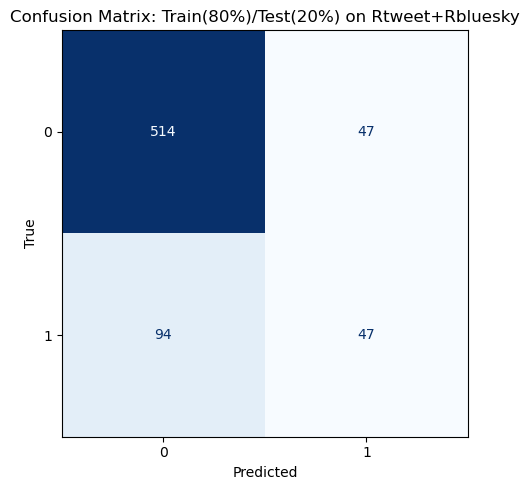

In [85]:
# Combine df_Rtweet and df_Rbluesky
df_R_combined = pd.concat([df_Rtweet, df_Rbluesky], ignore_index=True)

# Rename label column to 'label' for consistency if needed
if 'Educator' in df_R_combined.columns:
    df_R_combined = df_R_combined.rename(columns={'Educator': 'label'})

# Convert label to int
df_R_combined['label'] = df_R_combined['label'].astype(int)

# Split into train (80%) and test (20%) stratified
X = df_R_combined['text'].tolist()
y = df_R_combined['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Vectorize using TF-IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train LinearSVC
clf = LinearSVC()
clf.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred = clf.predict(X_test_tfidf)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')
print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
ax.set_title("Confusion Matrix: Train(80%)/Test(20%) on Rtweet+Rbluesky")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()
